In [47]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt

THRESHOLD_TIMESTAMPS = 5

In [48]:
def extract_json(filename: str):
    with open(filename, "r") as f:
        for line in f:
            session = json.loads(line)
            yield session["session"], session["events"]

In [49]:
sessions = []

for i, (session_id, eventstotal) in enumerate(extract_json("train.jsonl")):
    aids, timestamps, events_type = [], [], []
    for event in eventstotal:
        aids.append(event["aid"])
        timestamps.append(event["ts"])
        events_type.append(event["type"])
        
    sessions.append({
            "session_id": i,
            "events": {
            "aid": aids,
            "timestamps": timestamps,
            "events_type": events_type    
            },
        })
    if i >= 1000000:
        break

In [50]:
class OttoDataSetSession(Dataset):
    def __init__(self, session):
        self.session = session
        self.event_map = {"clicks":1, "carts": 2, "orders": 3}

    def __len__(self) -> int:
        return len(self.session)


    def __getitem__(self, index):
        session = self.session[index]
                 
        events = session["events"]
        
        aids = torch.tensor(events["aid"], dtype=torch.int64)
        
        timestamps = torch.tensor(events["timestamps"], dtype=torch.long)
        
        events_type = torch.tensor( [self.event_map[e] for e in events["events_type"]], dtype=torch.int64)
        return {
            "session_id": torch.tensor(session["session_id"], dtype=torch.int64),
            "aid": aids,
            "timestamps": timestamps,
            "type": events_type
        }
    

In [51]:
dataset = OttoDataSetSession(sessions)
print(len(dataset))

lenghts = []
for i in range(0, len(dataset)):
    sample = dataset[i]["timestamps"]
    lenghts.append(len(sample))

print(np.mean(lenghts))
print(f"The total of the median is for this total of {len(dataset)} {np.median(lenghts)}")


1000001
39.88959311040689
The total of the median is for this total of 1000001 14.0


In [52]:
sessions_in_dataset = OttoDataSetSession(sessions)
print(f"Total len of the Sessions: {len(sessions_in_dataset)}")

session_sample_lenght = []
for i in range(len(sessions_in_dataset)):
    sample = sessions_in_dataset[i]["timestamps"]
    if len(sample) >= THRESHOLD_TIMESTAMPS:
        session_sample_lenght.append(len(sample))

print(np.mean(session_sample_lenght))
print(f"The total of the median is for this total of {len(session_sample_lenght)} {np.median(session_sample_lenght)}")


Total len of the Session: 1000001
51.53134407196345
The total of the median is for this total of 761053 23.0


In [ ]:
total_sessions = len(sessions_in_dataset)
kept_sessions = len(session_sample_lenght)
lost_sessions = total_sessions - kept_sessions

percent_lost = (lost_sessions / total_sessions) * 100
print(f"{percent_lost:.2f}%")


-23.89%  # negative means lost


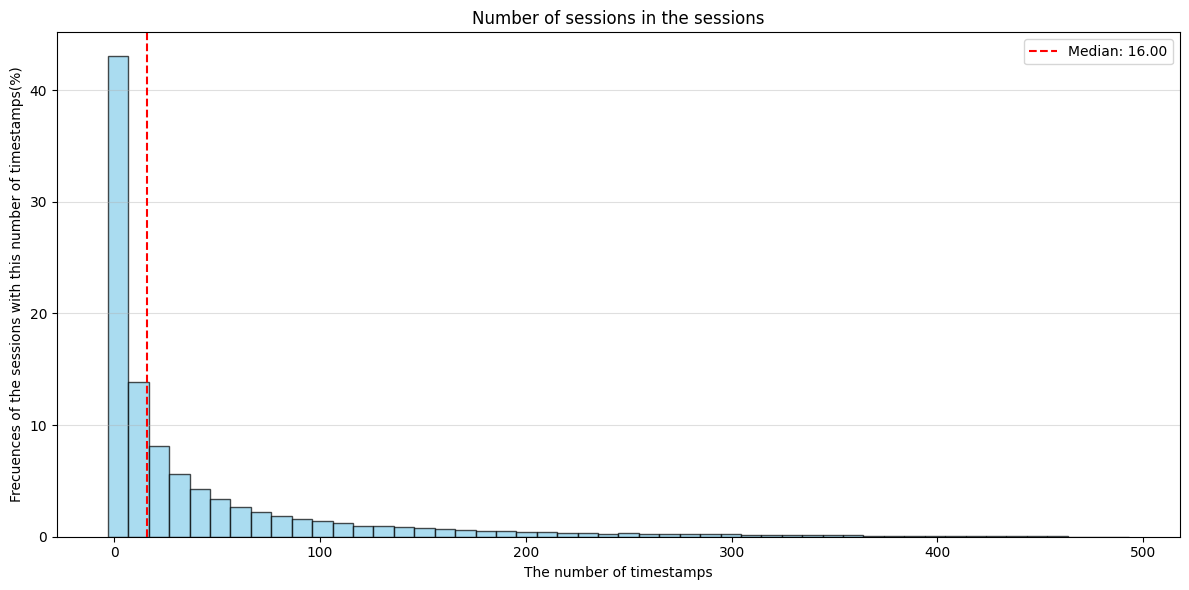

In [35]:

plt.figure(figsize=(12,6))
counts, bins, patches = plt.hist(lenghts, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True )



counts = counts * 100 * (bins[1] - bins[0])
plt.clf()
plt.bar(
    bins[:-1],
    counts,
    width=(bins[1] - bins[0]),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.axvline(np.median(lenghts), color="red", linestyle="--", label=f"Median: {np.median(lenghts):.2f}")
plt.title("Number of sessions in the sessions")
plt.xlabel("The number of timestamps")
plt.ylabel("Frecuences of the sessions with this number of timestamps(%)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

